<a href="https://colab.research.google.com/github/crazair/ML_Course/blob/main/Lecture5_IntroDL_CV/PT_DL_HT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание

В этом домашнем задании вы обучите полносвязную нейронную сеть для решения задачи классификации на датасете CIFAR-10.

Это домашнее задание оформлено в не совсем традиционном формате. Не хочется заставлять вас копировать код. Вы будете менять уже существующую архитектуру, а затем отвечать на вопросы.

## Задание 1

Запустите данный изначально код и замерьте качество (accuracy) на тестовых данных.

**Ответ:
Accuracy of the network on the test images: 48.83 %**


## Задание 2

Добавьте еще один полносвязный слой (перед выходным) из 100 нейронов + функцию активации ReLU и запустите обучение. Замерьте accuracy на тесте.


**Ответ:
Accuracy of the network on the test images: 51.53 %**


## Задание 3

Теперь обучите полносвязную сеть с несколькими линейными слоями с числом нейронов: 1024, 512, 256, 128, 64 соответственно + функцией ReLU на выходе из каждого внутреннего слоя. Замерьте accuracy.

**Ответ:
Accuracy of the network on the test images: 53.8 %**

## Задание 4

К архитектуре из предыдущего задания добавьте Dropout(0.2) перед слоями из 1024 и 256 нейронов. Увеличилась ли accuracy по сравнению с предыдущим заданием?

*P.S. Спросите у ChatGPT, что такое Dropout? Зачем он нужен?*

**Ответ:
Accuracy of the network on the test images: 51.99 %**

Dropout — это метод регуляризации, при котором во время обучения случайно отключается часть нейронов. Это нужно для того, чтобы сеть не переобучалась, не запоминала обучающие данные слишком точно и лучше работала на новых данных.

## Задание 5

Уберите Dropout, но добавьте BatchNorm перед входом в те же линейные слои. Увеличилась ли accuracy по сравнению с заданием 3?

*P.S. Спросите у ChatGPT, что такое BatchNorm? Зачем он нужен?*

**Ответ:
Accuracy of the network on the test images: 51.47 %**

BatchNorm — это слой нормализации, который приводит значения признаков к более стабильному виду внутри батча. Это нужно для того, чтобы обучение проходило быстрее и устойчивее, а модель легче сходилась.

## Задание 6

Теперь пробуйте что угодно:
* разное число линейных слоев
* разные функции активации (вместо ReLU)
* комбинации Dropout / BatchNorm
* наконец, попробуйте написать сверточную нейронную сеть! :)

Цель - добиться наибольшей accuracy на тесте.

--
Без свёртки: Accuracy of the network on the test images: 54.71 %

**Перехорд на CNN: Accuracy of the network on the test images: 91.19 %**

(CNN — это сверточная нейронная сеть, специально предназначенная для обработки изображений, потому что она учитывает их пространственную структуру. В отличие от полносвязной сети, CNN не превращает картинку просто в длинный вектор, а выделяет локальные признаки: границы, текстуры, части объектов и затем более сложные формы. Это особенно хорошо подходит для CIFAR-10, где важно распознавать объекты по визуальным шаблонам на небольших цветных изображениях.)


In [15]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import random
import numpy as np
from matplotlib import pyplot as plt

def seed():
    np.random.seed(0)
    random.seed(0)
    torch.manual_seed(0)
    torch.cuda.manual_seed_all(0)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed()


In [16]:
# Check Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Hyper-parameters
num_classes = 10
num_epochs = 30
batch_size = 128
learning_rate = 0.001

cuda


In [17]:
# MNIST dataset
# Transforms
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

# Datasets
train_dataset = torchvision.datasets.CIFAR10(
    root='../../data',
    train=True,
    transform=train_transform,
    download=True
)

test_dataset = torchvision.datasets.CIFAR10(
    root='../../data',
    train=False,
    transform=test_transform,
    download=True
)

In [18]:
# DataLoaders
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [19]:
# CNN model
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN(num_classes).to(device)

In [20]:
model

CNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, c

In [21]:
# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [22]:
train_loss_log = []
test_acc_log = []

# Train
total_step = len(train_loader)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], Loss: {loss.item():.4f}')

    scheduler.step()
    epoch_loss = running_loss / total_step
    train_loss_log.append(epoch_loss)

    # Evaluation after each epoch
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    test_acc_log.append(acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_loss:.4f} | Test Accuracy: {acc:.2f}%')


Epoch [1/30], Step [100/391], Loss: 1.6334
Epoch [1/30], Step [200/391], Loss: 1.2361
Epoch [1/30], Step [300/391], Loss: 1.1405
Epoch [1/30] | Train Loss: 1.3696 | Test Accuracy: 68.16%
Epoch [2/30], Step [100/391], Loss: 1.0266
Epoch [2/30], Step [200/391], Loss: 0.9131
Epoch [2/30], Step [300/391], Loss: 0.8551
Epoch [2/30] | Train Loss: 0.9199 | Test Accuracy: 73.55%
Epoch [3/30], Step [100/391], Loss: 0.6079
Epoch [3/30], Step [200/391], Loss: 0.6100
Epoch [3/30], Step [300/391], Loss: 0.7715
Epoch [3/30] | Train Loss: 0.7755 | Test Accuracy: 74.95%
Epoch [4/30], Step [100/391], Loss: 0.7039
Epoch [4/30], Step [200/391], Loss: 0.6991
Epoch [4/30], Step [300/391], Loss: 0.7311
Epoch [4/30] | Train Loss: 0.6902 | Test Accuracy: 79.85%
Epoch [5/30], Step [100/391], Loss: 0.6945
Epoch [5/30], Step [200/391], Loss: 0.5368
Epoch [5/30], Step [300/391], Loss: 0.4681
Epoch [5/30] | Train Loss: 0.6216 | Test Accuracy: 76.86%
Epoch [6/30], Step [100/391], Loss: 0.5438
Epoch [6/30], Step [20

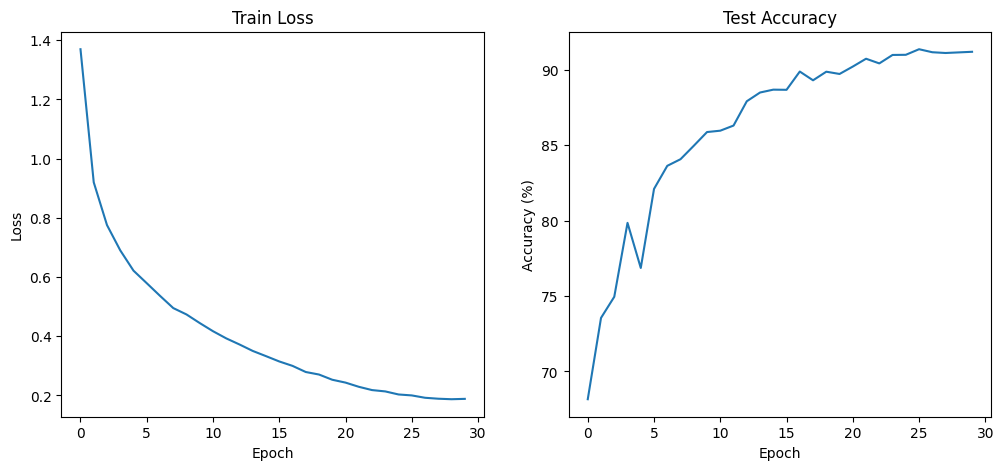

In [23]:
# Plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_log)
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(test_acc_log)
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.show()

In [24]:
# Final test accuracy
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the test images: {} %'.format(100 * correct / total))

# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')

Accuracy of the network on the test images: 91.19 %


Всего ошибок: 881


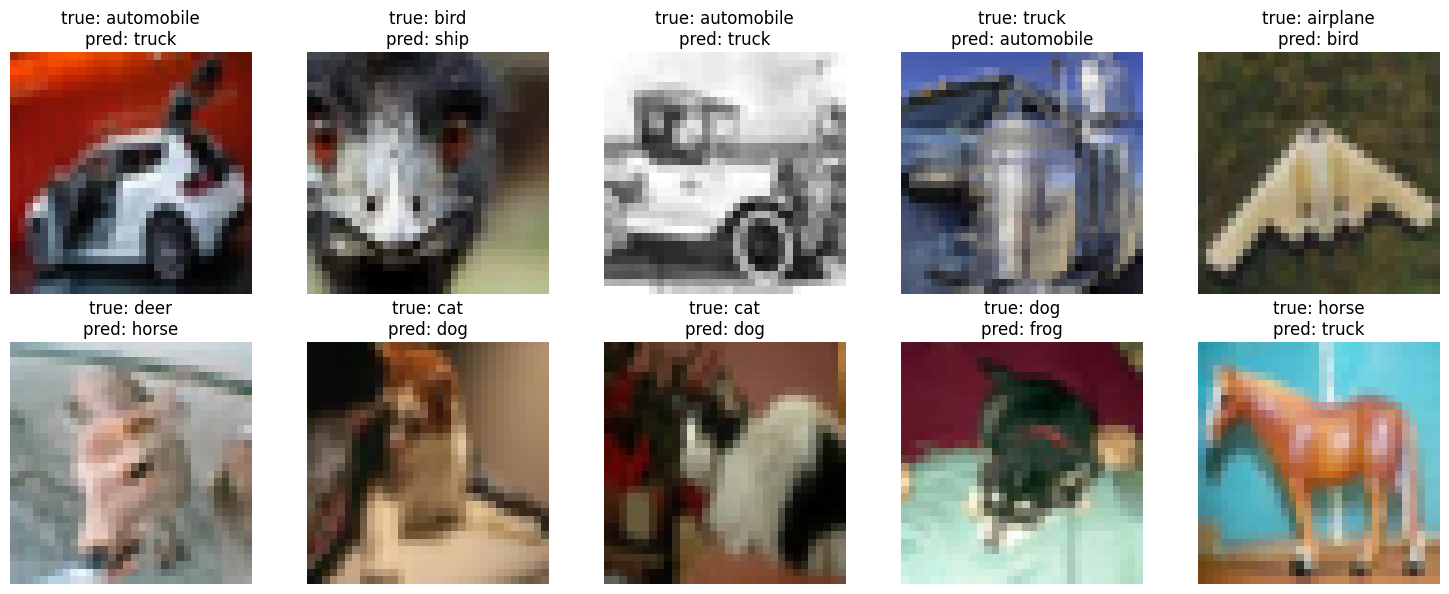

In [26]:
# Названия классов CIFAR-10
classes = test_dataset.classes

# Соберем ошибочные предсказания
wrong_images = []
wrong_labels = []
wrong_preds = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images_for_model = images.to(device)
        labels = labels.to(device)

        outputs = model(images_for_model)
        _, predicted = torch.max(outputs, 1)

        wrong_mask = predicted != labels

        if wrong_mask.any():
            wrong_images.extend(images[wrong_mask.cpu()])
            wrong_labels.extend(labels[wrong_mask].cpu())
            wrong_preds.extend(predicted[wrong_mask].cpu())

# Сколько показать
num_to_show = 10

print(f'Всего ошибок: {len(wrong_images)}')

plt.figure(figsize=(15, 6))
for i in range(min(num_to_show, len(wrong_images))):
    img = wrong_images[i]

    # denormalize для CIFAR-10 normalization
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = img * std + mean

    # ограничим значения в [0, 1]
    img = torch.clamp(img, 0, 1)

    # [C, H, W] -> [H, W, C]
    img = img.permute(1, 2, 0).numpy()

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"true: {classes[wrong_labels[i]]}\npred: {classes[wrong_preds[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()